<a href="https://colab.research.google.com/github/Fakhar001/AIC354-Machine-Learning-Fundamentals/blob/main/ML_Lab_3_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Real-life Regression Problem Analysis
In this notebook, we compare Linear Regression, Decision Trees, SVR, and Bayesian Ridge (Regression alternative to Naive Bayes) using the California Housing dataset.

## Section 1: Data Loading and Preprocessing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

display(X.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## Section 2: Algorithm Explanations & Formulas

### 1. Linear Regression
**Formula:** $y = \beta_0 + \sum_{i=1}^{n} \beta_i x_i + \epsilon$
- It assumes a linear relationship between features and target, minimizing the Residual Sum of Squares (RSS).

### 2. Decision Tree Regressor
**Mechanism:** Predicts $f(x) = \sum_{m=1}^{M} c_m I(x \in R_m)$
- It partitions the feature space into regions $R_m$ and predicts the mean value of the target for samples in that region.

### 3. Support Vector Regression (SVR)
**Formula:** Minimize $\frac{1}{2}||w||^2$ subject to $|y_i - (wx_i + b)| \le \epsilon$
- It looks for a function that has at most $\epsilon$ deviation from the actual targets.

### 4. Bayesian Ridge (Naive Bayes for Regression)
**Formula:** $p(y|\lambda) = \mathcal{N}(y|0, \lambda^{-1}I)$
- While Naive Bayes is for classification, Bayesian Ridge uses a probabilistic approach to regression by placing priors on coefficients.

## Section 3: Model Training and Metrics Collection

In [ ]:
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=7, random_state=42),
    "SVM (SVR)": SVR(kernel='rbf', C=1.0),
    "Bayesian Ridge": BayesianRidge()
}

results_list = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results_list.append({"Algorithm": name, "MSE": mse, "R2 Score": r2})

## Section 4: Final Comparison and Results

In [ ]:
results_df = pd.DataFrame(results_list)
display(results_df.sort_values(by='R2 Score', ascending=False))

best_algo = results_df.loc[results_df['R2 Score'].idxmax()]['Algorithm']
print(f"\nConclusion: The best algorithm based on R2 Score is {best_algo}.")

,Algorithm,MSE,R2 Score
2,SVM (SVR),0.357004,0.727563
1,Decision Tree,0.456586,0.651570
3,Bayesian Ridge,0.555831,0.575834
0,Linear Regression,0.555892,0.575788



Conclusion: The best algorithm based on R2 Score is SVM (SVR).


/tmp/ipykernel_4588/1189961798.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='R2 Score', data=results_df.sort_values(by='R2 Score', ascending=False), ax=axes[0], palette='viridis')


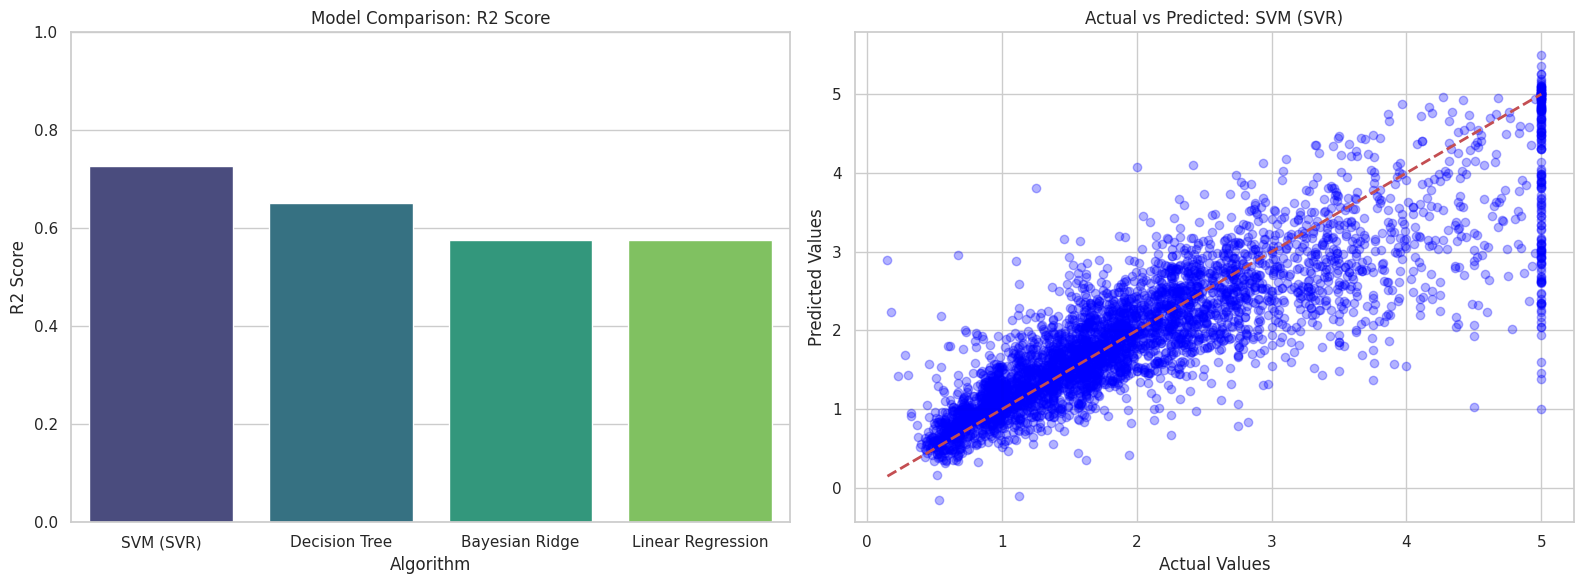

In [ ]:
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot R2 Score Comparison
sns.barplot(x='Algorithm', y='R2 Score', data=results_df.sort_values(by='R2 Score', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison: R2 Score')
axes[0].set_ylim(0, 1)

# 2. Plot Predicted vs Actual for the best model (SVR)
best_model_obj = models[best_algo]
y_pred_best = best_model_obj.predict(X_test_scaled)

axes[1].scatter(y_test, y_pred_best, alpha=0.3, color='blue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title(f'Actual vs Predicted: {best_algo}')

plt.tight_layout()
plt.show()

## Section 5: Practice Use-Case for Students

### Scenario: Real Estate Price Optimization
You are a Data Scientist for a property tech company. Your task is to provide an automated valuation model (AVM) for the California housing market. Stakeholders need a model that is robust enough to handle non-linear market trends but simple enough to be interpreted for high-level reporting.

### The Machine Learning Workflow
To solve this problem, you must follow these standard steps:
1. **Data Acquisition**: Fetching the California Housing dataset.
2. **Preprocessing**: Handling feature scaling (StandardScaler) and splitting data into training and testing sets.
3. **Algorithm Selection**: Implementing Linear Regression, Decision Trees, SVR, and Bayesian Ridge.
4. **Model Training**: Fitting the training data to the algorithms.
5. **Evaluation**: Using Mean Squared Error (MSE) and R-squared (R²) metrics.
6. **Visualization**: Analyzing residual plots and performance bars.

### Instructions for Students:
1. **Analyze the Results**: Look at the table in Section 4 and the visualizations in the previous cell.
2. **Identify Trade-offs**: While SVR might have the highest R², consider if a Decision Tree might be easier to explain to a non-technical manager.
3. **Final Decision**: Based on the metrics produced, which model would you deploy to production? Justify your choice by explaining the relationship between the mathematical approach of that model and the data distribution seen in the 'Actual vs Predicted' plot.